# Learning Grover — amplitude amplification, used to find an optimum

**`qcoptlib` learning series · notebook 2 (QAOA → **Grover** → QML)**

Grover's algorithm, built up until it *solves an optimization problem*: we watch amplitude
amplification concentrate probability on the answer, then use **Grover Adaptive Search (GAS)** to
find the maximum cut of a graph — the same problem the QAOA notebook solves, by a different quantum
route.

Everything here is an **exact statevector simulation in NumPy** (`qcoptlib.quantum.grover`), so it
runs instantly and is fully verifiable; the same operators map onto a Qiskit circuit for real
hardware (sketched at the end).

> **Status: in build.** Standard Grover, written from the textbook and framed for our optimization
> use — the amplitude-amplification maths and the simulator are unit-tested in the library.


## 1. The idea: search by amplifying the answer

Given $N = 2^n$ candidates and an **oracle** that recognises the $M$ good ones (it can *check* a
candidate, not *find* one), classical search needs $O(N/M)$ checks. Grover needs $O(\sqrt{N/M})$ —
a **quadratic speedup**. Two operators, repeated:

- **Oracle** — flips the *phase* of good states ($|x\rangle \to -|x\rangle$), marking them.
- **Diffuser** — reflects every amplitude about the mean ("inversion about the average"). A
  phase-flipped good state sits below the mean, so reflecting makes it **taller**. This is
  *amplitude amplification*.

Let's watch it on the amplitude vector directly.


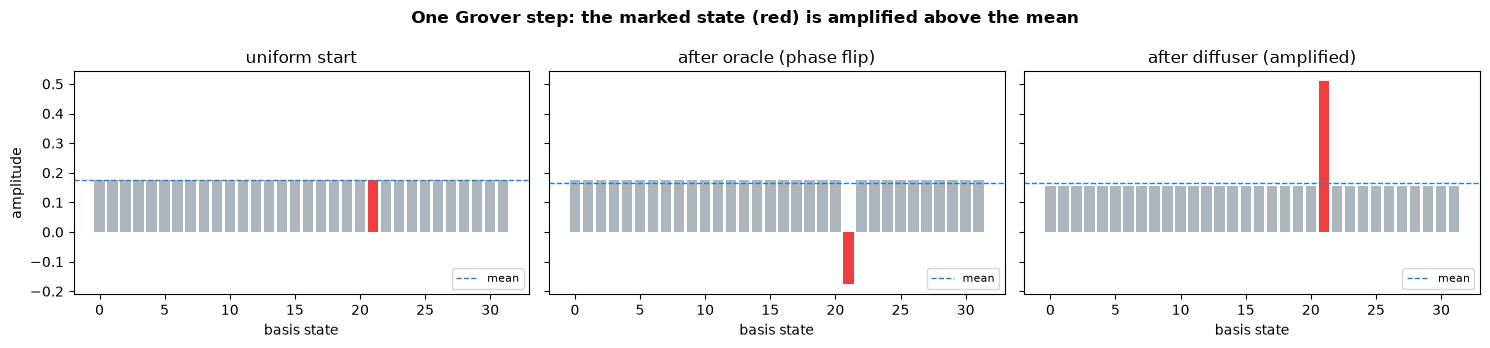

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qcoptlib.quantum.grover import (
    uniform_state, apply_oracle, apply_diffuser, grover_search,
    grover_optimal_iterations, grover_success_probability, grover_adaptive_search,
)

n = 5                      # N = 32 candidates
marked = [21]             # the single "good" state we search for
amp0 = uniform_state(n)
amp1 = apply_oracle(amp0, marked)      # after oracle: marked amplitude goes negative
amp2 = apply_diffuser(amp1)            # after diffuser: marked amplitude amplified

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5), sharey=True)
for ax, amp, title in [(axes[0], amp0, "uniform start"),
                       (axes[1], amp1, "after oracle (phase flip)"),
                       (axes[2], amp2, "after diffuser (amplified)")]:
    colors = ["#f03e3e" if i in marked else "#adb5bd" for i in range(len(amp))]
    ax.bar(range(len(amp)), amp, color=colors)
    ax.axhline(amp.mean(), ls="--", lw=1, color="#1c7ed6", label="mean")
    ax.set_title(title); ax.set_xlabel("basis state"); ax.legend(loc="lower right", fontsize=8)
axes[0].set_ylabel("amplitude")
plt.suptitle("One Grover step: the marked state (red) is amplified above the mean", fontweight="bold")
plt.tight_layout(); plt.show()


## 2. The geometry — and why "more iterations" can hurt

The state stays in the 2-D plane spanned by $|\text{good}\rangle$ and $|\text{bad}\rangle$; each
iteration rotates it by $2\theta$ toward $|\text{good}\rangle$, with $\sin\theta=\sqrt{M/N}$. After
$r$ steps the success probability is $\sin^2((2r+1)\theta)$, maximised at
$r^\star\approx\frac{\pi}{4}\sqrt{N/M}$ — and iterating *past* it **overshoots** and falls again.


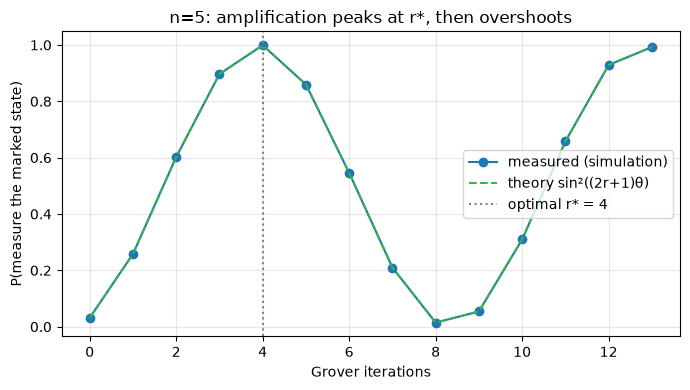

peak success 0.999 at r*=4; at 2r*+1=9 it falls to 0.054


In [2]:
r_star = grover_optimal_iterations(n, len(marked))
# measured success per iteration from the exact simulation, vs theory
amp, history = grover_search(n, marked, 3 * r_star + 1)
measured = [(a ** 2)[marked[0]] for a in history]
theory = [grover_success_probability(n, len(marked), r) for r in range(len(history))]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(len(measured)), measured, "o-", label="measured (simulation)")
ax.plot(range(len(theory)), theory, "--", color="#37b24d", label="theory sin²((2r+1)θ)")
ax.axvline(r_star, ls=":", color="grey", label=f"optimal r* = {r_star}")
ax.set_xlabel("Grover iterations"); ax.set_ylabel("P(measure the marked state)")
ax.set_title(f"n={n}: amplification peaks at r*, then overshoots"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"peak success {measured[r_star]:.3f} at r*={r_star}; "
      f"at 2r*+1={2*r_star+1} it falls to {measured[2*r_star+1]:.3f}")


## 3. Grover to find the optimum — Grover Adaptive Search on Max-Cut

Grover *searches*; to *optimise* we wrap it in a shrinking-threshold loop (**Grover Adaptive
Search**, the quantum analogue of Dürr–Høyer minimum finding):

1. Mark every state with cost **below the current best**.
2. Grover-search for one and measure it.
3. Lower the threshold to the found cost; repeat until nothing better remains.

Our problem is **Max-Cut** on a small graph — split the nodes into two sets cutting as many edges
as possible. We minimise $\text{cost}(x) = -\text{(edges cut)}$, so GAS's minimum is the maximum
cut. (The QAOA notebook solves this exact problem the variational way — nice to see both.)


6 nodes, 8 edges | max cut = 8 edges | 2 optimal configs (e.g. 010101)


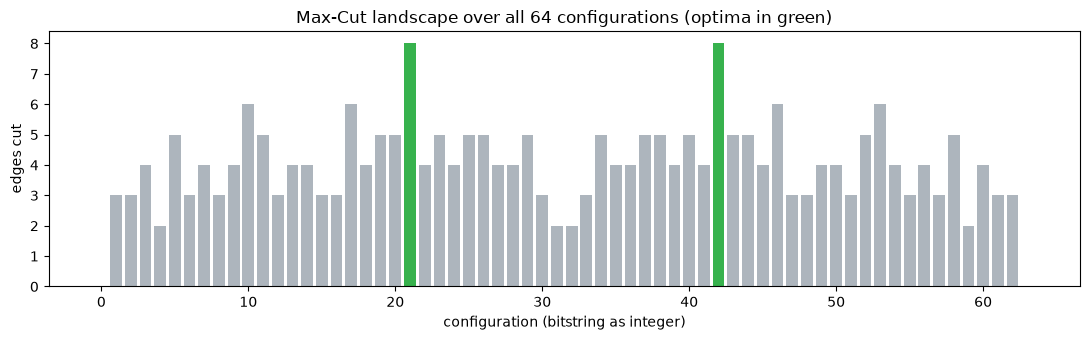

In [3]:
# a 6-node graph (N = 64 configurations); cost(x) = -(edges cut)
n = 6
edges = [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 0), (0, 3), (1, 4)]

def cut_edges(x_int):
    bits = [(x_int >> i) & 1 for i in range(n)]
    return sum(bits[i] != bits[j] for i, j in edges)

costs = np.array([-cut_edges(x) for x in range(2 ** n)], dtype=float)   # minimise -> max cut
opt_cut = int(-costs.min())
optima = np.flatnonzero(costs == costs.min())
print(f"{n} nodes, {len(edges)} edges | max cut = {opt_cut} edges | "
      f"{len(optima)} optimal configs (e.g. {optima[0]:0{n}b})")

fig, ax = plt.subplots(figsize=(11, 3.5))
colors = ["#37b24d" if c == costs.min() else "#adb5bd" for c in costs]
ax.bar(range(len(costs)), -costs, color=colors)     # plot edges-cut (=-cost)
ax.set_xlabel("configuration (bitstring as integer)"); ax.set_ylabel("edges cut")
ax.set_title("Max-Cut landscape over all 64 configurations (optima in green)")
plt.tight_layout(); plt.show()


GAS found config 010101 with 8 edges cut (OPTIMAL)


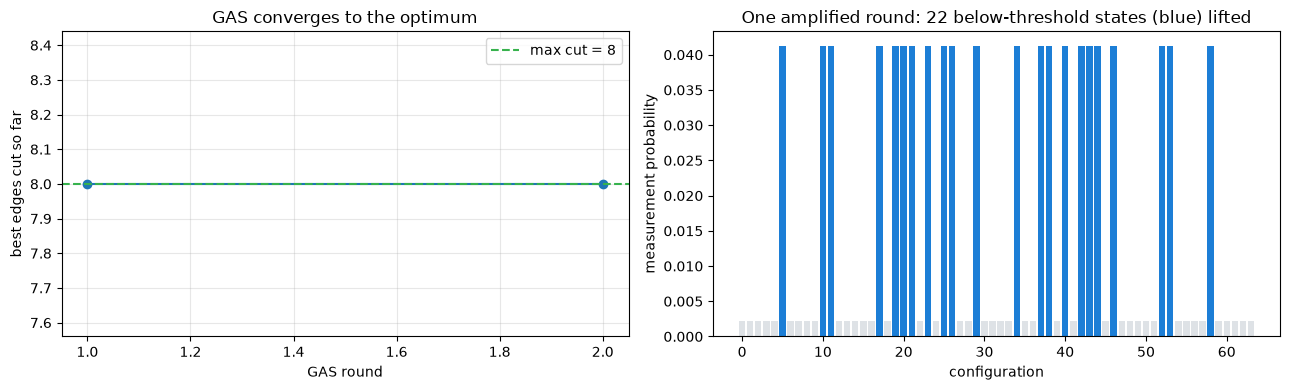

In [4]:
# run Grover Adaptive Search on the cost landscape
res = grover_adaptive_search(costs, rounds=15, seed=2)
print(f"GAS found config {res.best_index:0{n}b} with {int(-res.best_cost)} edges cut "
      f"({'OPTIMAL' if res.best_cost == costs.min() else 'suboptimal'})")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# (a) convergence: best cut found per round
best_cut = [-c for c in res.best_per_round]
axes[0].plot(range(1, len(best_cut) + 1), best_cut, "o-")
axes[0].axhline(opt_cut, ls="--", color="#37b24d", label=f"max cut = {opt_cut}")
axes[0].set_xlabel("GAS round"); axes[0].set_ylabel("best edges cut so far")
axes[0].set_title("GAS converges to the optimum"); axes[0].legend(); axes[0].grid(alpha=0.3)

# (b) one amplified round: probabilities with the threshold's marked set highlighted
threshold = np.median(costs)
marked = np.flatnonzero(costs < threshold)
amp, _ = grover_search(n, marked, max(1, grover_optimal_iterations(n, marked.size)))
probs = amp ** 2
bar_colors = ["#1c7ed6" if i in set(marked.tolist()) else "#dee2e6" for i in range(len(probs))]
axes[1].bar(range(len(probs)), probs, color=bar_colors)
axes[1].set_xlabel("configuration"); axes[1].set_ylabel("measurement probability")
axes[1].set_title(f"One amplified round: {marked.size} below-threshold states (blue) lifted")
plt.tight_layout(); plt.show()


## 4. On real hardware — the Qiskit circuit

The NumPy simulation above is exact but classical. On a quantum backend the *same* two operators
are gates: the diffuser is $H^{\otimes n} X^{\otimes n} (\text{MCZ}) X^{\otimes n} H^{\otimes n}$,
and the oracle is a multi-controlled phase flip of the marked bitstrings. Sketch (Qiskit):

```python
from qiskit import QuantumCircuit
def diffuser(n):
    qc = QuantumCircuit(n)
    qc.h(range(n)); qc.x(range(n))
    qc.h(n-1); qc.mcx(list(range(n-1)), n-1); qc.h(n-1)     # multi-controlled Z
    qc.x(range(n)); qc.h(range(n)); return qc
# Grover: H^n, then r × (oracle, diffuser), then measure — run on AerSimulator.
```

For a *real* GAS the oracle "cost(x) < threshold" is built as a quantum **comparator** circuit —
Qiskit ships this as `GroverOptimizer` in `qiskit-optimization`. Our simulation marks the
below-threshold states directly, which shows the logic without the comparator plumbing.


## 5. Grover vs QAOA — when to use which

| | **Grover / GAS** | **QAOA** |
|---|---|---|
| Guarantee | Provable **quadratic** speedup over brute force | Heuristic — no guarantee at finite depth |
| Needs | An efficient **oracle** (a comparator for the cost) | A good **ansatz** + tuned angles |
| Circuit | Deep: $\sim\sqrt{N}$ iterations × oracle depth | Shallow-ish: $p$ cost/mixer layers |
| Uses structure | No — cost is a black box | Yes — encodes the cost Hamiltonian |
| NISQ-friendly | Hard (depth) | Better (shallow, variational) |
| Best when | Unstructured search with a cheap oracle | Structured QUBO on near-term hardware |

We just solved the *same* Max-Cut with GAS (this notebook) and QAOA (`01_qaoa.ipynb`). For the
telecom QUBOs in this program (antenna tilt, dispatch, routing) the practical fit is **QAOA** — the
cost is a natural QUBO and near-term depth matters; **Grover/GAS** is the provable-speedup reference
point and the tool when the problem is genuinely unstructured search.


## Summary & references

- Grover = oracle (phase-flip solutions) + diffuser (reflect about the mean), repeated
  $r^\star\approx(\pi/4)\sqrt{N/M}$ times; success $\sin^2((2r+1)\theta)$ oscillates, so
  overshooting hurts.
- **GAS** turns search into optimization via a shrinking-threshold oracle; here it found the
  maximum cut. `qiskit-optimization`'s `GroverOptimizer` builds the comparator oracle for real QUBOs.
- **Choose QAOA** for our structured QUBOs on near-term hardware; **Grover/GAS** for unstructured
  search with a cheap oracle and when a provable speedup matters.

References: Grover (1996); Boyer, Brassard, Høyer, Tapp (1998), tight bounds; Dürr & Høyer (1996),
quantum minimum finding; Gilliam, Woerner, Gonciulea (2021), *Grover Adaptive Search for Constrained
Polynomial Binary Optimization*; Qiskit `GroverOptimizer`.

*Library used: `qcoptlib.quantum.grover` — exact statevector Grover (`grover_search`), the geometry
helpers, and `grover_adaptive_search` (the optimizer). All tested.*
